# 01_PREPARATION_DONNEES

## Objectif

Ce notebook couvre toute la phase de préparation des données pour le projet Home Credit.

On cherche à produire un dataset :

- propre ;
- documenté ;
- fusionné à la bonne granularité ;
- enrichi avec des features pertinentes ;
- encodé de façon compatible avec la modélisation ;
- prêt à être repris dans le notebook d'entraînement.

Le fil directeur suit directement les consignes du projet :

- explorer les sources brutes une par une ;
- vérifier les formats, les doublons et les valeurs manquantes ;
- identifier les clés de jointure ;
- mesurer le déséquilibre de la cible ;
- justifier les choix de nettoyage, d'encodage et de fusion ;
- construire un dataset final propre et enrichi.


In [17]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.impute import SimpleImputer

try:
    import missingno as msno
except ModuleNotFoundError:
    msno = None
    print("Package optionnel 'missingno' non trouvé : les graphiques dédiés aux valeurs manquantes seront remplacés par un affichage simplifié.")

def resolve_project_root(start_path: Path) -> Path:
    # On remonte plusieurs niveaux pour supporter les lancements
    # depuis la racine du projet, notebooks/, ou un sous-dossier voisin.
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError(
        "Impossible de localiser la racine du projet contenant 'src/' et 'data/'."
    )

project_root = resolve_project_root(Path.cwd())

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.Fonctions_EDA import (
    RAW_TABLES,
    build_full_dataset,
    duplicate_report,
    drop_low_information_columns,
    missing_values_table,
    summarize_binary_flags,
    summarize_categorical_association,
    summarize_categorical_modalities,
)

data_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

# Paramètres de pilotage du notebook.
# Ils servent uniquement à rendre l'analyse lisible et reproductible.
debug_num_rows = None
eda_sample_size = 25_000
numeric_corr_threshold = 0.03
numeric_plot_threshold = 0.05
top_numeric_plot_n = 6
top_numeric_heatmap_n = 12
binary_min_obs = 1_000
binary_min_gap = 0.01
categorical_cramers_threshold = 0.02
categorical_min_obs = 300
top_categorical_plot_n = 10
top_categorical_modalities_n = 5

# Cette table de configuration n'est pas "inférée" automatiquement.
# Elle synthétise notre compréhension métier et structurelle du jeu de données :
# - clé primaire de la table quand elle existe ;
# - clé parente pour rattacher la table à un niveau supérieur ;
# - granularité attendue avant toute jointure.
join_key_config = {
    "application_train": {"main_key": "SK_ID_CURR", "parent_key": None, "expected_grain": "1 ligne par client"},
    "application_test": {"main_key": "SK_ID_CURR", "parent_key": None, "expected_grain": "1 ligne par client"},
    "bureau": {"main_key": "SK_ID_BUREAU", "parent_key": "SK_ID_CURR", "expected_grain": "plusieurs lignes par client"},
    "bureau_balance": {"main_key": None, "parent_key": "SK_ID_BUREAU", "expected_grain": "historique mensuel par crédit bureau"},
    "previous_application": {"main_key": "SK_ID_PREV", "parent_key": "SK_ID_CURR", "expected_grain": "plusieurs demandes par client"},
    "pos_cash_balance": {"main_key": None, "parent_key": "SK_ID_PREV", "expected_grain": "historique mensuel par demande"},
    "installments_payments": {"main_key": None, "parent_key": "SK_ID_PREV", "expected_grain": "plusieurs paiements par demande"},
    "credit_card_balance": {"main_key": None, "parent_key": "SK_ID_PREV", "expected_grain": "historique mensuel par carte"},
}

def sample_for_plot(df, sample_size=eda_sample_size):
    # On échantillonne seulement pour les graphiques afin de garder
    # une exécution fluide sans changer les statistiques calculées.
    if len(df) > sample_size:
        return df.sample(n=sample_size, random_state=42)
    return df.copy()

def select_informative_numeric_columns(
    df,
    target_col="TARGET",
    min_corr_abs=numeric_corr_threshold,
    top_n=top_numeric_heatmap_n,
    max_missing_ratio=0.40,
    min_unique_values=10,
):
    # On filtre les variables numériques avant affichage :
    # 1. on enlève l'identifiant et la cible ;
    # 2. on garde uniquement des variables avec un minimum de variation ;
    # 3. on privilégie celles qui ont un signal minimal et pas trop de valeurs manquantes.
    numeric_cols = [
        col
        for col in df.select_dtypes(include=[np.number]).columns
        if col not in {target_col, "SK_ID_CURR"} and df[col].dropna().nunique() >= min_unique_values
    ]

    if not numeric_cols or target_col not in df.columns:
        return []

    corr = df[numeric_cols].corrwith(df[target_col]).abs().rename("correlation_abs")
    missing_ratio = df[numeric_cols].isna().mean().rename("missing_ratio")

    report = pd.concat([corr, missing_ratio], axis=1).sort_values(
        ["correlation_abs", "missing_ratio"],
        ascending=[False, True],
    )
    filtered = report.loc[
        (report["correlation_abs"] >= min_corr_abs)
        & (report["missing_ratio"] <= max_missing_ratio)
    ]

    if filtered.empty:
        return report.head(top_n).index.tolist()
    return filtered.head(top_n).index.tolist()

def build_parameter_guide():
    return pd.DataFrame(
        [
            {
                "parametre": "debug_num_rows",
                "valeur": debug_num_rows,
                "a_quoi_ca_sert": "Limite le nombre de lignes lues pour faire un test rapide.",
                "ou_c_est_utilise": "Chargement des CSV bruts et construction du dataset enrichi.",
            },
            {
                "parametre": "eda_sample_size",
                "valeur": eda_sample_size,
                "a_quoi_ca_sert": "Taille maximale de l'échantillon utilisé uniquement pour les graphiques.",
                "ou_c_est_utilise": "Fonction sample_for_plot et visualisations lourdes.",
            },
            {
                "parametre": "numeric_corr_threshold",
                "valeur": numeric_corr_threshold,
                "a_quoi_ca_sert": "Seuil minimal pour garder une variable numérique dans les heatmaps filtrées.",
                "ou_c_est_utilise": "Sélection des variables numériques à afficher dans les matrices de corrélation.",
            },
            {
                "parametre": "numeric_plot_threshold",
                "valeur": numeric_plot_threshold,
                "a_quoi_ca_sert": "Seuil plus strict pour ne tracer que les distributions numériques les plus utiles.",
                "ou_c_est_utilise": "Sélection de top_numeric_to_plot.",
            },
            {
                "parametre": "top_numeric_plot_n",
                "valeur": top_numeric_plot_n,
                "a_quoi_ca_sert": "Nombre maximum de variables numériques détaillées en courbes.",
                "ou_c_est_utilise": "Bloc de visualisation des distributions par TARGET.",
            },
            {
                "parametre": "top_numeric_heatmap_n",
                "valeur": top_numeric_heatmap_n,
                "a_quoi_ca_sert": "Nombre maximum de variables dans la heatmap numérique.",
                "ou_c_est_utilise": "Sélection de numeric_heatmap_cols et des features dérivées corrélées.",
            },
            {
                "parametre": "binary_min_obs",
                "valeur": binary_min_obs,
                "a_quoi_ca_sert": "Écarte les modalités binaires trop rares pour être interprétables.",
                "ou_c_est_utilise": "Filtrage du tableau binary_flag_target_gap.",
            },
            {
                "parametre": "binary_min_gap",
                "valeur": binary_min_gap,
                "a_quoi_ca_sert": "N'affiche que les flags binaires avec un écart de risque suffisamment visible.",
                "ou_c_est_utilise": "Sélection du graphique des variables binaires.",
            },
            {
                "parametre": "categorical_cramers_threshold",
                "valeur": categorical_cramers_threshold,
                "a_quoi_ca_sert": "Seuil minimal du V de Cramer pour retenir une variable catégorielle.",
                "ou_c_est_utilise": "Filtrage des variables catégorielles les plus liées à TARGET.",
            },
            {
                "parametre": "categorical_min_obs",
                "valeur": categorical_min_obs,
                "a_quoi_ca_sert": "Écarte les modalités catégorielles trop rares dans l'analyse détaillée.",
                "ou_c_est_utilise": "Filtrage de categorical_modalities_filtered.",
            },
            {
                "parametre": "top_categorical_plot_n",
                "valeur": top_categorical_plot_n,
                "a_quoi_ca_sert": "Nombre maximum de variables catégorielles mises en avant.",
                "ou_c_est_utilise": "Graphique horizontal basé sur le V de Cramer.",
            },
            {
                "parametre": "top_categorical_modalities_n",
                "valeur": top_categorical_modalities_n,
                "a_quoi_ca_sert": "Nombre de variables catégorielles retenues pour l'étude des modalités.",
                "ou_c_est_utilise": "Construction de top_categorical_variables.",
            },
        ]
    )

print("Python executable :", sys.executable)
print("Projet :", project_root)
print("Dossier des données brutes :", data_dir)
print("Dossier de sortie :", processed_dir)


Python executable : c:\Users\kevin\Documents\P6\P6_MLOps_1-2\.venv\Scripts\python.exe
Projet : C:\Users\kevin\Documents\P6\P6_MLOps_1-2
Dossier des données brutes : C:\Users\kevin\Documents\P6\P6_MLOps_1-2\data\raw
Dossier de sortie : C:\Users\kevin\Documents\P6\P6_MLOps_1-2\data\processed


**Paramètres du notebook**

Les paramètres ci-dessous servent à piloter la lisibilité et la reproductibilité du notebook.
Ils ne changent pas la logique métier du projet ; ils règlent surtout :

- la taille des échantillons affichés ;
- les seuils minimaux pour considérer qu'une variable mérite d'être visualisée ;
- le nombre maximum d'éléments affichés dans chaque graphique.


In [2]:
parameter_guide = build_parameter_guide()
display(parameter_guide)


,parametre,valeur,a_quoi_ca_sert,ou_c_est_utilise
0,debug_num_rows,NaN,Limite le nombre de lignes lues pour faire un ...,Chargement des CSV bruts et construction du da...
1,eda_sample_size,25000.00,Taille maximale de l'échantillon utilisé uniqu...,Fonction sample_for_plot et visualisations lou...
2,numeric_corr_threshold,0.03,Seuil minimal pour garder une variable numériq...,Sélection des variables numériques à afficher ...
3,numeric_plot_threshold,0.05,Seuil plus strict pour ne tracer que les distr...,Sélection de top_numeric_to_plot.
4,top_numeric_plot_n,6.00,Nombre maximum de variables numériques détaill...,Bloc de visualisation des distributions par TA...
5,top_numeric_heatmap_n,12.00,Nombre maximum de variables dans la heatmap nu...,Sélection de numeric_heatmap_cols et des featu...
6,binary_min_obs,1000.00,Écarte les modalités binaires trop rares pour ...,Filtrage du tableau binary_flag_target_gap.
7,binary_min_gap,0.01,N'affiche que les flags binaires avec un écart...,Sélection du graphique des variables binaires.
8,categorical_cramers_threshold,0.02,Seuil minimal du V de Cramer pour retenir une ...,Filtrage des variables catégorielles les plus ...
9,categorical_min_obs,300.00,Écarte les modalités catégorielles trop rares ...,Filtrage de categorical_modalities_filtered.


**Étape 1 - Vérifier les fichiers bruts**

On commence par contrôler que toutes les sources attendues sont bien présentes. Cela permet d'éviter de lancer une fusion incomplète ou de construire un dataset final incohérent.


In [3]:
raw_files_report = pd.DataFrame(
    [
        {
            "table_name": table_name,
            "file_name": file_name,
            "exists": (data_dir / file_name).exists(),
            "size_mb": round((data_dir / file_name).stat().st_size / 1024 / 1024, 2),
        }
        for table_name, file_name in RAW_TABLES.items()
    ]
)

display(raw_files_report)
raw_files_report.to_csv(processed_dir / "raw_files_report.csv", index=False)


,table_name,file_name,exists,size_mb
0,application_train,application_train.csv,True,158.44
1,application_test,application_test.csv,True,25.34
2,bureau,bureau.csv,True,162.14
3,bureau_balance,bureau_balance.csv,True,358.19
4,previous_application,previous_application.csv,True,386.21
5,pos_cash_balance,POS_CASH_balance.csv,True,374.51
6,installments_payments,installments_payments.csv,True,689.62
7,credit_card_balance,credit_card_balance.csv,True,404.91


**Étape 2 - Inspecter chaque source séparément**

Ici, l'objectif est double :

- vérifier les colonnes disponibles dans chaque source ;
- documenter les clés utiles à la fusion.

Les colonnes `main_key`, `parent_key` et `expected_grain` ne sont pas "devinées" par le code.
Elles viennent de la structure métier du dataset Home Credit :

- `main_key` = identifiant propre à la table quand il existe ;
- `parent_key` = identifiant permettant de rattacher la table au niveau supérieur ;
- `expected_grain` = niveau logique de la table, par exemple "une ligne par client" ou "plusieurs lignes par demande".

Ensuite, l'étape 3 vérifie empiriquement que cette lecture métier est cohérente avec les duplications observées.


In [4]:
source_overview_rows = []

for table_name, file_name in RAW_TABLES.items():
    # On lit seulement quelques lignes pour documenter la structure
    # sans charger inutilement toute la table en mémoire.
    preview = pd.read_csv(data_dir / file_name, nrows=5)
    join_spec = join_key_config[table_name]
    source_overview_rows.append(
        {
            "table_name": table_name,
            "file_name": file_name,
            "n_columns": preview.shape[1],
            "main_key": join_spec["main_key"],
            "parent_key": join_spec["parent_key"],
            "expected_grain": join_spec["expected_grain"],
            "contains_target": "TARGET" in preview.columns,
            "first_columns": ", ".join(preview.columns[:8]),
        }
    )

source_overview = pd.DataFrame(source_overview_rows)
display(source_overview)
source_overview.to_csv(processed_dir / "source_overview.csv", index=False)


,table_name,file_name,n_columns,main_key,parent_key,expected_grain,contains_target,first_columns
0,application_train,application_train.csv,122,SK_ID_CURR,None,1 ligne par client,True,"SK_ID_CURR, TARGET, NAME_CONTRACT_TYPE, CODE_G..."
1,application_test,application_test.csv,121,SK_ID_CURR,None,1 ligne par client,False,"SK_ID_CURR, NAME_CONTRACT_TYPE, CODE_GENDER, F..."
2,bureau,bureau.csv,17,SK_ID_BUREAU,SK_ID_CURR,plusieurs lignes par client,False,"SK_ID_CURR, SK_ID_BUREAU, CREDIT_ACTIVE, CREDI..."
3,bureau_balance,bureau_balance.csv,3,None,SK_ID_BUREAU,historique mensuel par crédit bureau,False,"SK_ID_BUREAU, MONTHS_BALANCE, STATUS"
4,previous_application,previous_application.csv,37,SK_ID_PREV,SK_ID_CURR,plusieurs demandes par client,False,"SK_ID_PREV, SK_ID_CURR, NAME_CONTRACT_TYPE, AM..."
5,pos_cash_balance,POS_CASH_balance.csv,8,None,SK_ID_PREV,historique mensuel par demande,False,"SK_ID_PREV, SK_ID_CURR, MONTHS_BALANCE, CNT_IN..."
6,installments_payments,installments_payments.csv,8,None,SK_ID_PREV,plusieurs paiements par demande,False,"SK_ID_PREV, SK_ID_CURR, NUM_INSTALMENT_VERSION..."
7,credit_card_balance,credit_card_balance.csv,23,None,SK_ID_PREV,historique mensuel par carte,False,"SK_ID_PREV, SK_ID_CURR, MONTHS_BALANCE, AMT_BA..."


**Étape 3 - Documenter les clés de jointure et la granularité**

C'est un point de vigilance majeur : on ne joint jamais des tables détaillées directement sur `SK_ID_CURR` sans gérer la duplication. Les tables enfants doivent d'abord être agrégées à la maille client.


In [5]:
grain_rows = []

for table_name, file_name in RAW_TABLES.items():
    spec = join_key_config[table_name]
    usecols = [col for col in [spec["main_key"], spec["parent_key"]] if col is not None]

    # On ne lit que les clés nécessaires pour vérifier la granularité.
    key_df = pd.read_csv(data_dir / file_name, usecols=usecols, nrows=debug_num_rows)

    row = {
        "table_name": table_name,
        "expected_grain": spec["expected_grain"],
        "rows": int(len(key_df)),
        "main_key": spec["main_key"],
        "parent_key": spec["parent_key"],
    }

    if spec["main_key"] is not None:
        main_stats = duplicate_report(key_df, spec["main_key"])
        row["main_key_unique"] = main_stats["unique_keys"]
        row["main_key_duplicated_ratio"] = main_stats["duplicated_ratio"]
    else:
        row["main_key_unique"] = np.nan
        row["main_key_duplicated_ratio"] = np.nan

    if spec["parent_key"] is not None:
        parent_stats = duplicate_report(key_df, spec["parent_key"])
        row["parent_key_unique"] = parent_stats["unique_keys"]
        row["parent_key_duplicated_ratio"] = parent_stats["duplicated_ratio"]
    else:
        row["parent_key_unique"] = np.nan
        row["parent_key_duplicated_ratio"] = np.nan

    grain_rows.append(row)

raw_grain_report = pd.DataFrame(grain_rows)
display(raw_grain_report)
raw_grain_report.to_csv(processed_dir / "raw_grain_report.csv", index=False)


,table_name,expected_grain,rows,main_key,parent_key,main_key_unique,main_key_duplicated_ratio,parent_key_unique,parent_key_duplicated_ratio
0,application_train,1 ligne par client,307511,SK_ID_CURR,None,307511.0,0.0,NaN,NaN
1,application_test,1 ligne par client,48744,SK_ID_CURR,None,48744.0,0.0,NaN,NaN
2,bureau,plusieurs lignes par client,1716428,SK_ID_BUREAU,SK_ID_CURR,1716428.0,0.0,305811.0,0.8218
3,bureau_balance,historique mensuel par crédit bureau,27299925,None,SK_ID_BUREAU,NaN,NaN,817395.0,0.9701
4,previous_application,plusieurs demandes par client,1670214,SK_ID_PREV,SK_ID_CURR,1670214.0,0.0,338857.0,0.7971
5,pos_cash_balance,historique mensuel par demande,10001358,None,SK_ID_PREV,NaN,NaN,936325.0,0.9064
6,installments_payments,plusieurs paiements par demande,13605401,None,SK_ID_PREV,NaN,NaN,997752.0,0.9267
7,credit_card_balance,historique mensuel par carte,3840312,None,SK_ID_PREV,NaN,NaN,104307.0,0.9728


**Lecture des résultats**

Les contrôles de granularité confirment la lecture métier du schéma :

- `application_train` (`307 511`) et `application_test` (`48 744`) sont bien à une ligne par client ;
- `bureau` et `previous_application` dupliquent fortement `SK_ID_CURR` (`82,18 %` et `79,71 %` de duplication) ;
- les tables historiques sont encore plus détaillées : `bureau_balance` (`97,01 %`), `POS_CASH_balance` (`90,64 %`), `installments_payments` (`92,67 %`) et `credit_card_balance` (`97,28 %`) dupliquent massivement leur clé parente.

Décision :
on ne fera jamais de jointure directe de ces tables détaillées sur le client. Elles doivent d'abord être agrégées à la maille `SK_ID_CURR`, sinon on gonfle artificiellement le nombre de lignes et on introduit un biais majeur dans le modèle.


**Étape 4 - Charger les tables principales et vérifier le déséquilibre de classes**

On inspecte ensuite `application_train` et `application_test`, car la cible `TARGET` n'existe que dans le train. C'est aussi ici qu'on documente le déséquilibre de classes, enjeu métier central du scoring.


application_train shape : (307511, 122)
application_test shape  : (48744, 121)
TARGET présente dans train : True
TARGET présente dans test  : False


,TARGET,count,ratio
0,0,282686,0.919271
1,1,24825,0.080729


Taux de défaut global : 8.0729%


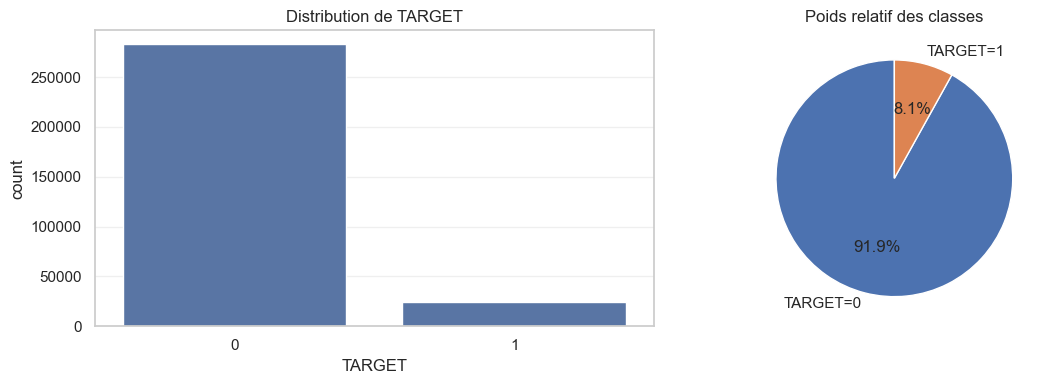

In [6]:
app_train = pd.read_csv(data_dir / "application_train.csv", nrows=debug_num_rows)
app_test = pd.read_csv(data_dir / "application_test.csv", nrows=debug_num_rows)

print("application_train shape :", app_train.shape)
print("application_test shape  :", app_test.shape)
print("TARGET présente dans train :", "TARGET" in app_train.columns)
print("TARGET présente dans test  :", "TARGET" in app_test.columns)

target_distribution = (
    app_train["TARGET"]
    .value_counts(dropna=False)
    .rename_axis("TARGET")
    .reset_index(name="count")
    .sort_values("TARGET")
)
target_distribution["ratio"] = target_distribution["count"] / len(app_train)

display(target_distribution)
target_distribution.to_csv(processed_dir / "target_distribution.csv", index=False)

print(f"Taux de défaut global : {app_train['TARGET'].mean():.4%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=app_train, x="TARGET", ax=axes[0])
axes[0].set_title("Distribution de TARGET")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].pie(
    target_distribution["count"],
    labels=[f"TARGET={int(v)}" for v in target_distribution["TARGET"]],
    autopct="%.1f%%",
    startangle=90,
)
axes[1].set_title("Poids relatif des classes")

plt.tight_layout()
plt.show()


**Interprétation**

La cible est nettement déséquilibrée : `282 686` clients sont en classe `0` (`91,93 %`) contre `24 825` en classe `1` (`8,07 %`).

Décisions :

- ne pas piloter la suite avec l'accuracy ;
- privilégier des métriques comme `PR AUC`, `ROC AUC` et surtout une métrique métier de coût ;
- conserver une validation croisée stratifiée ;
- prévoir plus tard un travail de seuil de décision plutôt qu'un simple `0.5` par défaut.


**Étape 5 - Qualité des variables dans la table principale**

Avant toute fusion, on documente les types, les valeurs manquantes et les doublons de `application_train`. On évite ici de supprimer brutalement des colonnes : on cherche d'abord à comprendre ce qu'elles portent.


Rapport de duplication sur SK_ID_CURR :
{'rows': 307511, 'unique_keys': 307511, 'duplicated_keys': 0, 'duplicated_ratio': 0.0}

Répartition des dtypes :
float64    65
int64      41
object     16
Name: count, dtype: int64


,missing_count,missing_ratio,dtype,nunique
COMMONAREA_AVG,214865,0.698723,float64,3181
COMMONAREA_MODE,214865,0.698723,float64,3128
COMMONAREA_MEDI,214865,0.698723,float64,3202
NONLIVINGAPARTMENTS_AVG,213514,0.694330,float64,386
NONLIVINGAPARTMENTS_MODE,213514,0.694330,float64,167
NONLIVINGAPARTMENTS_MEDI,213514,0.694330,float64,214
FONDKAPREMONT_MODE,210295,0.683862,object,4
LIVINGAPARTMENTS_AVG,210199,0.683550,float64,1868
LIVINGAPARTMENTS_MODE,210199,0.683550,float64,736
LIVINGAPARTMENTS_MEDI,210199,0.683550,float64,1097


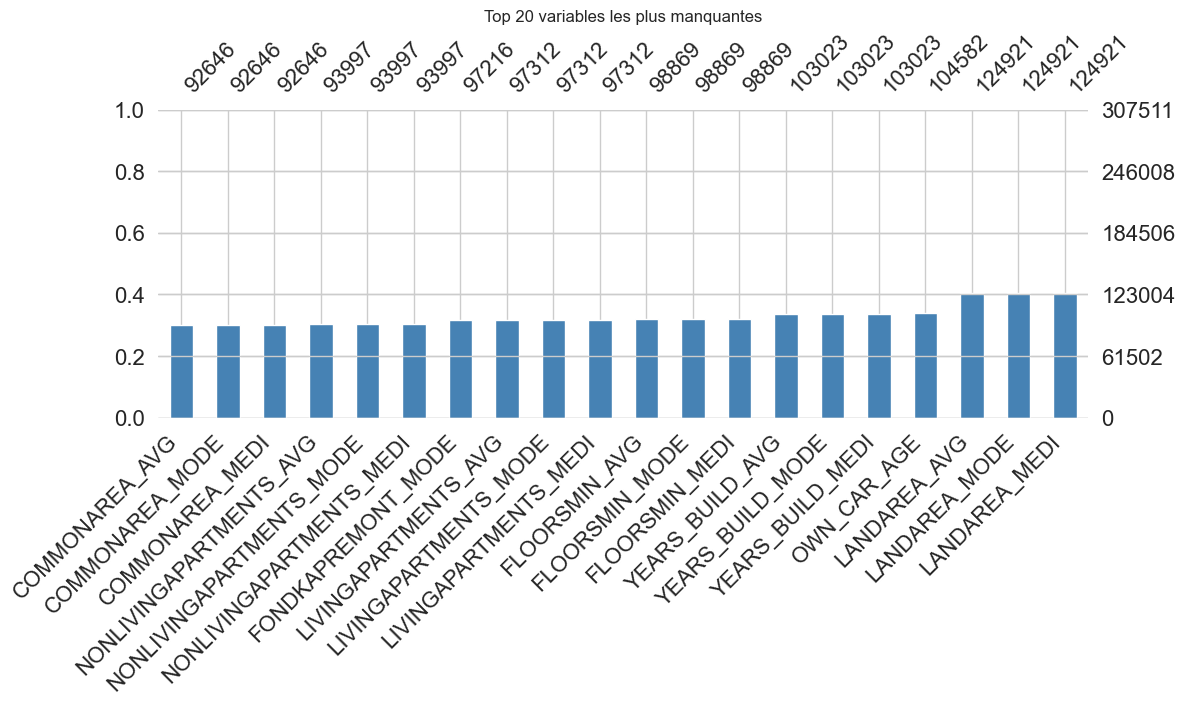

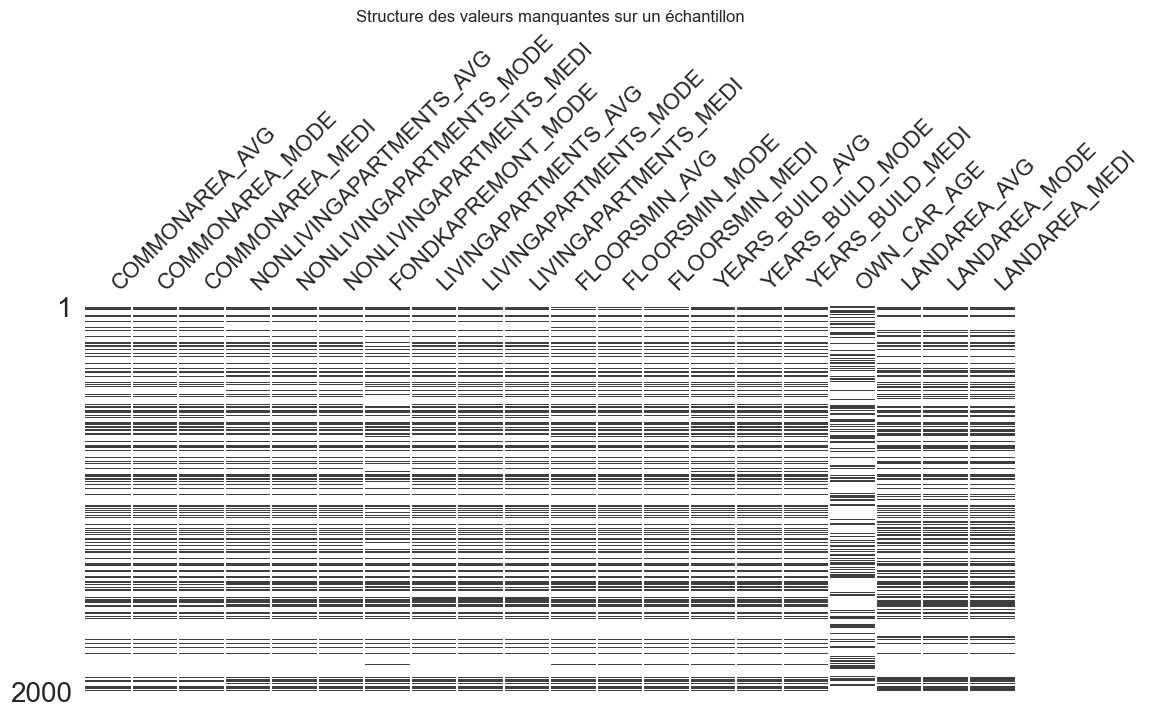

In [8]:
application_missing_report = missing_values_table(app_train)
application_duplicate_report = duplicate_report(app_train, key="SK_ID_CURR")

print("Rapport de duplication sur SK_ID_CURR :")
print(application_duplicate_report)

print("\nRépartition des dtypes :")
print(app_train.dtypes.astype(str).value_counts())

display(application_missing_report.head(20))
application_missing_report.to_csv(processed_dir / "application_missing_report.csv")

top_missing_columns = application_missing_report.head(20).index.tolist()

if msno is not None:
    msno.bar(
        app_train[top_missing_columns],
        color="steelblue",
        figsize=(12, 4),
    )
    plt.title("Top 20 variables les plus manquantes")
    plt.show()

    missing_sample = app_train[top_missing_columns].sample(
        n=min(2000, len(app_train)),
        random_state=42,
    )

    try:
        msno.matrix(
            missing_sample,
            figsize=(12, 5),
            sparkline=False,
        )
        plt.title("Structure des valeurs manquantes sur un échantillon")
        plt.show()
    except RuntimeError as exc:
        print(f"Visualisation missingno matrix ignorée : {exc}")
else:
    fig, ax = plt.subplots(figsize=(12, 4))
    missing_preview = application_missing_report.head(20).sort_values("missing_ratio")
    ax.barh(
        missing_preview.index,
        missing_preview["missing_ratio"],
        color="steelblue",
        alpha=0.8,
    )
    ax.set_title("Top 20 variables les plus manquantes")
    ax.set_xlabel("Part de valeurs manquantes")
    ax.set_ylabel("Variable")
    plt.tight_layout()
    plt.show()


**Justification**

Le diagnostic montre deux éléments importants :

- `SK_ID_CURR` ne contient pas de doublons dans `application_train`, donc la table principale est propre à la maille client ;
- plusieurs variables de logement et d'environnement dépassent `50 %` de valeurs manquantes, certaines allant au-delà de `65 %`.

Décision :
on ne supprime pas ces colonnes au stade EDA uniquement parce qu'elles sont très incomplétes. Elles sont conservées jusqu'à la phase de fusion / encodage, puis filtrées plus tard uniquement si elles deviennent réellement non informatives ou inexploitées pour la modélisation.


**Étape 6 - Variables numériques les plus liées à la cible**

On ne trace pas une matrice géante illisible. On filtre d'abord les variables numériques les plus informatives à partir de leur corrélation avec `TARGET`, puis on ne visualise qu'un sous-ensemble utile.


Top 20 variables numériques par corrélation absolue avec TARGET :


,variable,correlation_target,correlation_abs,missing_ratio,n_unique,median_target_0,median_target_1,median_gap,median_gap_abs
0,EXT_SOURCE_3,-0.178919,0.178919,0.198253,814,0.546023,0.379100,-0.166923,0.166923
1,EXT_SOURCE_2,-0.160472,0.160472,0.002146,119831,0.573905,0.440381,-0.133524,0.133524
2,EXT_SOURCE_1,-0.155317,0.155317,0.563811,114584,0.517452,0.361675,-0.155776,0.155776
3,DAYS_BIRTH,0.078239,0.078239,0.000000,17460,-15877.000000,-14282.000000,1595.000000,1595.000000
4,REGION_RATING_CLIENT_W_CITY,0.060893,0.060893,0.000000,3,2.000000,2.000000,0.000000,0.000000
5,REGION_RATING_CLIENT,0.058899,0.058899,0.000000,3,2.000000,2.000000,0.000000,0.000000
6,DAYS_LAST_PHONE_CHANGE,0.055218,0.055218,0.000003,3773,-776.000000,-594.000000,182.000000,182.000000
7,DAYS_ID_PUBLISH,0.051457,0.051457,0.000000,6168,-3295.000000,-2797.000000,498.000000,498.000000
8,DAYS_EMPLOYED,-0.044932,0.044932,0.000000,12574,-1235.000000,-1034.000000,201.000000,201.000000
9,FLOORSMAX_AVG,-0.044003,0.044003,0.497608,403,0.166700,0.166700,0.000000,0.000000


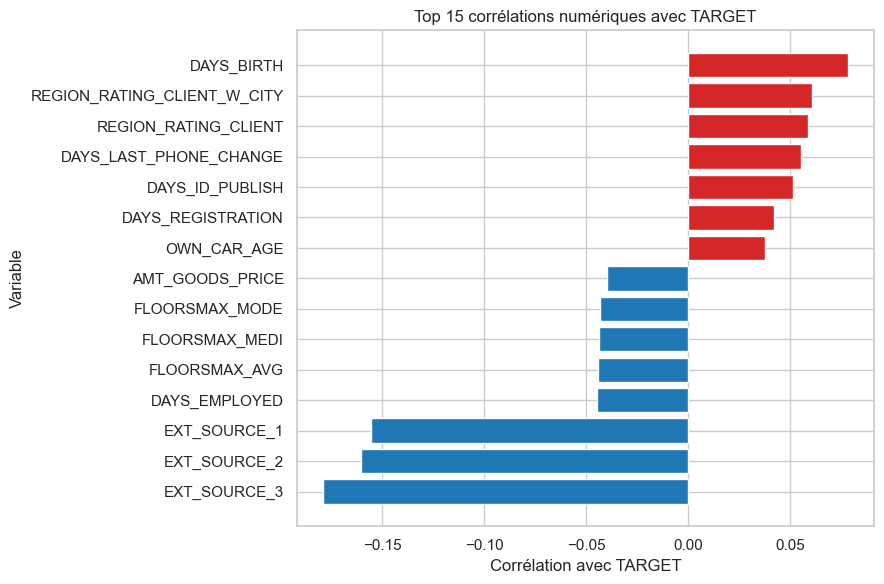

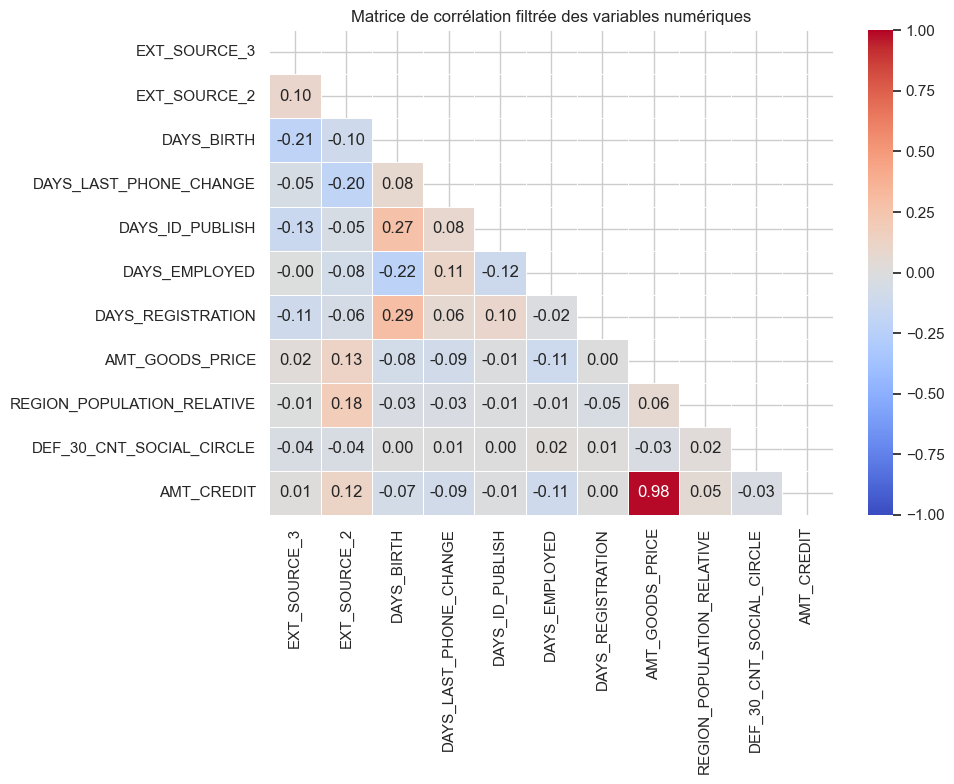

In [9]:
target_col = "TARGET"

numeric_cols = [
    col
    for col in app_train.select_dtypes(include=[np.number]).columns.tolist()
    if col not in {target_col, "SK_ID_CURR"} and app_train[col].dropna().nunique() > 2
]

numeric_missing_rate = app_train[numeric_cols].isna().mean().rename("missing_ratio")
numeric_nunique = app_train[numeric_cols].nunique(dropna=True).rename("n_unique")

numeric_corr = (
    app_train[numeric_cols]
    .corrwith(app_train[target_col])
    .rename("correlation_target")
    .to_frame()
)
numeric_corr["correlation_abs"] = numeric_corr["correlation_target"].abs()

median_by_target = (
    app_train.groupby(target_col)[numeric_cols]
    .median()
    .T
    .rename(columns={0: "median_target_0", 1: "median_target_1"})
)
median_by_target["median_gap"] = (
    median_by_target["median_target_1"] - median_by_target["median_target_0"]
)
median_by_target["median_gap_abs"] = median_by_target["median_gap"].abs()

numeric_target_report = (
    numeric_corr
    .join(numeric_missing_rate, how="left")
    .join(numeric_nunique, how="left")
    .join(median_by_target, how="left")
    .sort_values(["correlation_abs", "median_gap_abs"], ascending=[False, False])
    .reset_index(names="variable")
)

top_numeric_to_plot = select_informative_numeric_columns(
    app_train,
    target_col=target_col,
    min_corr_abs=numeric_plot_threshold,
    top_n=top_numeric_plot_n,
)
numeric_heatmap_cols = select_informative_numeric_columns(
    app_train,
    target_col=target_col,
    min_corr_abs=numeric_corr_threshold,
    top_n=top_numeric_heatmap_n,
)
numeric_corr_lookup = numeric_target_report.set_index("variable")["correlation_target"].to_dict()

print("Top 20 variables numériques par corrélation absolue avec TARGET :")
display(numeric_target_report.head(20))

numeric_target_report.to_csv(processed_dir / "numeric_target_correlation.csv", index=False)
numeric_target_report[
    [
        "variable",
        "missing_ratio",
        "n_unique",
        "median_target_0",
        "median_target_1",
        "median_gap",
        "median_gap_abs",
    ]
].to_csv(processed_dir / "numeric_median_gap.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 6))
top_corr_display = numeric_target_report.head(15).sort_values("correlation_target")
ax.barh(
    top_corr_display["variable"],
    top_corr_display["correlation_target"],
    color=["tab:red" if value > 0 else "tab:blue" for value in top_corr_display["correlation_target"]],
)
ax.set_title("Top 15 corrélations numériques avec TARGET")
ax.set_xlabel("Corrélation avec TARGET")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

if numeric_heatmap_cols:
    heatmap_sample = sample_for_plot(app_train[numeric_heatmap_cols])
    heatmap_sample = heatmap_sample.loc[
        :,
        heatmap_sample.nunique(dropna=True) > 1,
    ]

    # La corrélation de Spearman est plus robuste ici qu'une corrélation
    # purement linéaire pour comparer des distributions parfois asymétriques.
    corr_matrix = heatmap_sample.corr(method="spearman")
    if corr_matrix.shape[0] >= 2:
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(
            corr_matrix,
            mask=mask,
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            ax=ax,
        )
        ax.set_title("Matrice de corrélation filtrée des variables numériques")
        plt.tight_layout()
        plt.show()


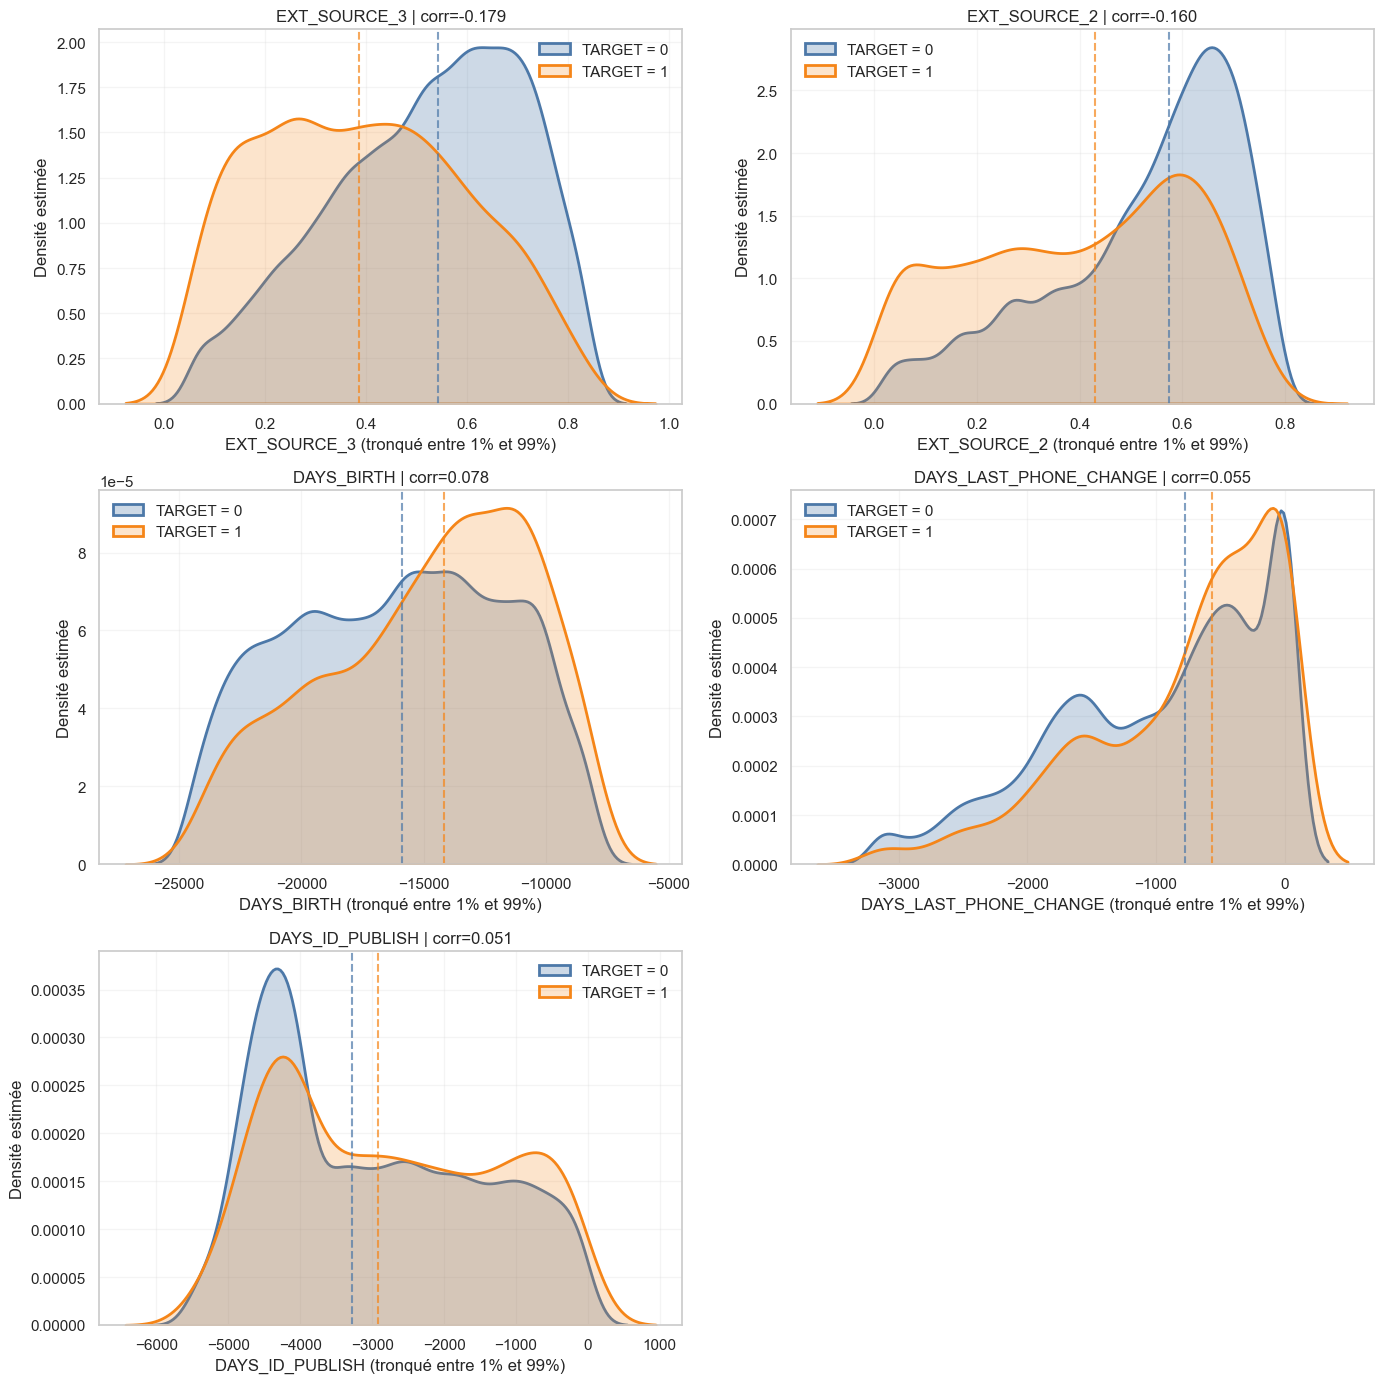

In [ ]:
if top_numeric_to_plot:
    plot_sample = sample_for_plot(app_train[[target_col] + top_numeric_to_plot])

    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes = axes.flatten()

    for ax, column in zip(axes, top_numeric_to_plot):
        temp = plot_sample[[column, target_col]].dropna().copy()
        lower = temp[column].quantile(0.01)
        upper = temp[column].quantile(0.99)

        if pd.notna(lower) and pd.notna(upper) and lower < upper:
            temp["value_display"] = temp[column].clip(lower=lower, upper=upper)
        else:
            temp["value_display"] = temp[column]

        temp_0 = temp.loc[temp[target_col] == 0, "value_display"]
        temp_1 = temp.loc[temp[target_col] == 1, "value_display"]

        if temp_0.nunique() > 1:
            sns.kdeplot(
                x=temp_0,
                fill=True,
                alpha=0.28,
                linewidth=2,
                color="#4C78A8",
                label="TARGET = 0",
                ax=ax,
            )
        if temp_1.nunique() > 1:
            sns.kdeplot(
                x=temp_1,
                fill=True,
                alpha=0.22,
                linewidth=2,
                color="#F58518",
                label="TARGET = 1",
                ax=ax,
            )

        medians = temp.groupby(target_col)["value_display"].median().to_dict()
        if 0 in medians:
            ax.axvline(medians[0], color="#4C78A8", linestyle="--", alpha=0.7) 
        if 1 in medians:
            ax.axvline(medians[1], color="#F58518", linestyle="--", alpha=0.7)

        ax.set_title(f"{column} | corr={numeric_corr_lookup.get(column, np.nan):.3f}")
        ax.set_xlabel(f"{column} (tronqué entre 1% et 99%)")
        ax.set_ylabel("Densité estimée")
        ax.grid(True, alpha=0.2)
        ax.legend(frameon=False)

    for ax in axes[len(top_numeric_to_plot):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


**Interprétation**

Les variables numériques brutes les plus informatives sont trés cohérentes métier :

- `EXT_SOURCE_3`, `EXT_SOURCE_2` et `EXT_SOURCE_1` sont les trois signaux les plus discriminants vis-à-vis du risque ;
- l'âge via `DAYS_BIRTH` apporte aussi un signal non négligeable ;
- des variables comme `DAYS_LAST_PHONE_CHANGE` et `DAYS_ID_PUBLISH` ressortent également.

Décisions :

- conserver impérativement les `EXT_SOURCE` et leurs dérivées ;
- ne visualiser que les variables numériques qui dépassent un minimum de signal pour garder des graphiques lisibles ;
- préparer des features dérivées simples autour de la stabilité du client, de l'âge et du comportement de crédit.


**Étape 7 - Variables binaires et variables catégorielles**

Les variables catégorielles ne se lisent pas avec une simple corrélation linéaire. On utilise donc :

- l'écart de taux de défaut pour les flags binaires ;
- le V de Cramer pour les variables catégorielles ;
- une analyse des modalités seulement sur les variables vraiment informatives.


,variable,modalite,nb_obs,part_obs,nb_target_1,taux_target_1,ecart_vs_taux_global,ratio_vs_taux_global,ecart_abs
56,FLAG_DOCUMENT_13,1,1084,0.003525,30,0.027675,-0.053054,0.342818,0.053054
25,REG_CITY_NOT_LIVE_CITY,1,24039,0.078173,2939,0.122260,0.041531,1.514449,0.041531
62,FLAG_DOCUMENT_16,1,3053,0.009928,150,0.049132,-0.031597,0.608605,0.031597
8,FLAG_EMP_PHONE,0,55386,0.180111,2991,0.054003,-0.026726,0.668941,0.026726
1,NAME_CONTRACT_TYPE,Revolving loans,29279,0.095213,1604,0.054783,-0.025946,0.678609,0.025946
27,REG_CITY_NOT_WORK_CITY,1,70867,0.230454,7520,0.106114,0.025385,1.314453,0.025385
42,FLAG_DOCUMENT_6,1,27078,0.088055,1507,0.055654,-0.025075,0.689395,0.025075
66,FLAG_DOCUMENT_18,1,2500,0.008130,142,0.056800,-0.023929,0.703590,0.023929
48,FLAG_DOCUMENT_9,1,1198,0.003896,74,0.061770,-0.018959,0.765150,0.018959
29,LIVE_CITY_NOT_WORK_CITY,1,55215,0.179555,5503,0.099665,0.018936,1.234565,0.018936


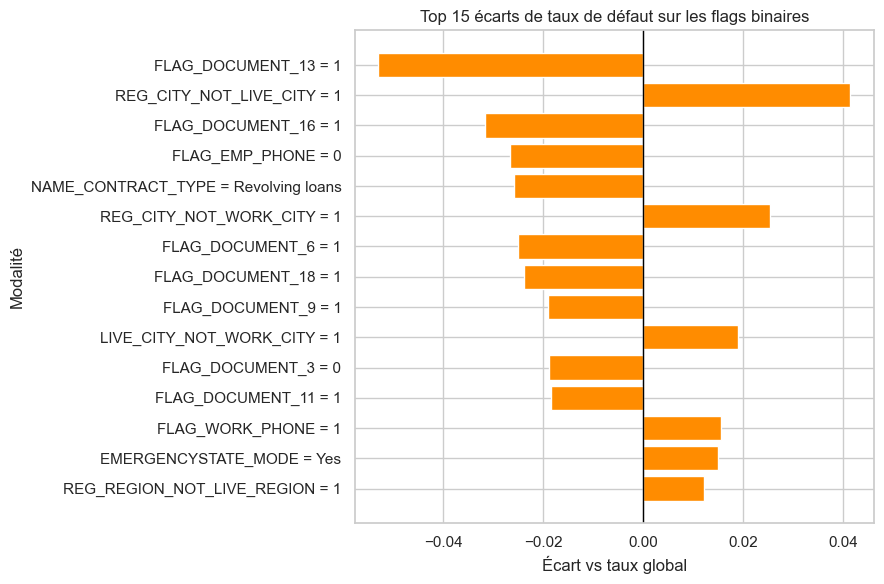

In [11]:
binary_flag_target_gap = summarize_binary_flags(app_train, target_col=target_col)
binary_flag_display = binary_flag_target_gap.loc[
    (binary_flag_target_gap["nb_obs"] >= binary_min_obs)
    & (binary_flag_target_gap["ecart_abs"] >= binary_min_gap)
].copy()

if binary_flag_display.empty:
    binary_flag_display = binary_flag_target_gap.head(15).copy()

display(binary_flag_display.head(20))
binary_flag_target_gap.to_csv(processed_dir / "binary_flag_target_gap.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 6))
top_flags = (
    binary_flag_display.head(15)
    .iloc[::-1]
    .assign(label=lambda df_: df_["variable"] + " = " + df_["modalite"].astype(str))
)
ax.barh(top_flags["label"], top_flags["ecart_vs_taux_global"], color="darkorange")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Top 15 écarts de taux de défaut sur les flags binaires")
ax.set_xlabel("Écart vs taux global")
ax.set_ylabel("Modalité")
plt.tight_layout()
plt.show()


Variables catégorielles les plus associées à TARGET :


,variable,chi2,p_value,nb_modalites,cramers_v
0,OCCUPATION_TYPE,1975.082752,0.000000e+00,19,0.079776
1,ORGANIZATION_TYPE,1609.240636,5.224541e-299,58,0.071048
2,NAME_INCOME_TYPE,1253.470808,1.928146e-266,8,0.063667
3,NAME_EDUCATION_TYPE,1019.213187,2.447681e-219,5,0.057458
4,CODE_GENDER,920.791334,1.129022e-200,3,0.054661
5,WALLSMATERIAL_MODE,599.041379,3.916842e-125,8,0.043878
6,EMERGENCYSTATE_MODE,547.975997,1.019821e-119,3,0.042136
7,HOUSETYPE_MODE,509.405086,4.369310e-110,4,0.040581
8,NAME_FAMILY_STATUS,504.694083,7.744842e-107,6,0.040311
9,NAME_HOUSING_TYPE,420.556190,1.099089e-88,6,0.036761


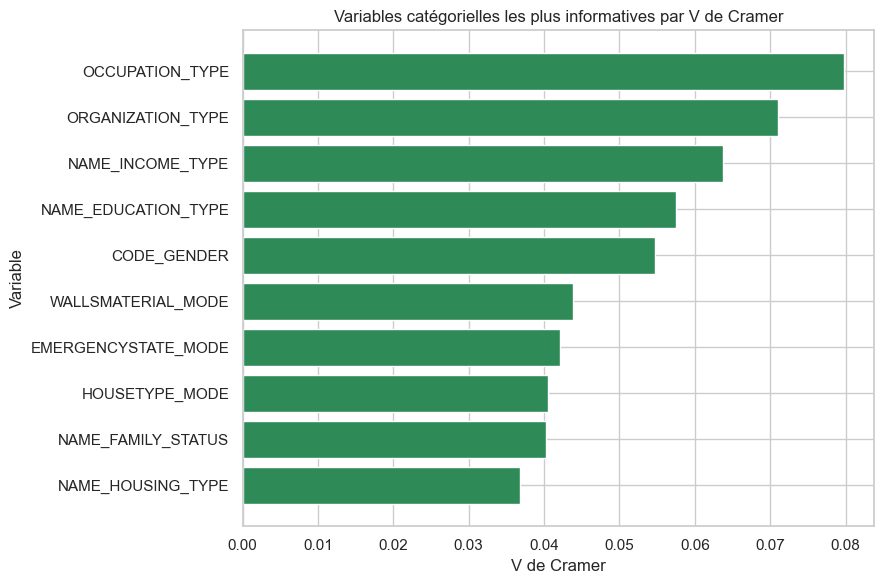

Modalités les plus à risque parmi les variables catégorielles les plus informatives :


,variable,modalite,nb_obs,part_obs,nb_target_1,taux_target_1,ecart_vs_taux_global,ratio_vs_taux_global,ecart_abs
9,OCCUPATION_TYPE,Low-skill Laborers,2093,0.006806,359,0.171524,0.090795,2.124695,0.090795
73,ORGANIZATION_TYPE,Transport: type 3,1187,0.003860,187,0.157540,0.076811,1.951472,0.076811
57,ORGANIZATION_TYPE,Restaurant,1811,0.005889,212,0.117062,0.036334,1.450069,0.036334
26,ORGANIZATION_TYPE,Construction,6721,0.021856,785,0.116798,0.036069,1.446796,0.036069
4,OCCUPATION_TYPE,Drivers,18603,0.060495,2107,0.113261,0.032532,1.402985,0.032532
17,OCCUPATION_TYPE,Waiters/barmen staff,1348,0.004384,152,0.112760,0.032031,1.396771,0.032031
33,ORGANIZATION_TYPE,Industry: type 1,1039,0.003379,115,0.110683,0.029955,1.371051,0.029955
88,NAME_EDUCATION_TYPE,Lower secondary,3816,0.012409,417,0.109277,0.028548,1.353627,0.028548
16,OCCUPATION_TYPE,Security staff,6721,0.021856,722,0.107424,0.026696,1.330683,0.026696
39,ORGANIZATION_TYPE,Industry: type 3,3278,0.010660,348,0.106162,0.025433,1.315048,0.025433


Modalités les plus protectrices parmi les variables catégorielles les plus informatives :


,variable,modalite,nb_obs,part_obs,nb_target_1,taux_target_1,ecart_vs_taux_global,ratio_vs_taux_global,ecart_abs
36,ORGANIZATION_TYPE,Industry: type 12,369,0.001200,14,0.037940,-0.042788,0.469973,0.042788
69,ORGANIZATION_TYPE,Trade: type 6,631,0.002052,29,0.045959,-0.034770,0.569298,0.034770
0,OCCUPATION_TYPE,Accountants,9813,0.031911,474,0.048303,-0.032426,0.598340,0.032426
60,ORGANIZATION_TYPE,Security Ministries,1974,0.006419,96,0.048632,-0.032097,0.602415,0.032097
75,ORGANIZATION_TYPE,University,1327,0.004315,65,0.048983,-0.031746,0.606756,0.031746
53,ORGANIZATION_TYPE,Police,2341,0.007613,117,0.049979,-0.030750,0.619093,0.030750
50,ORGANIZATION_TYPE,Military,2634,0.008566,135,0.051253,-0.029476,0.634877,0.029476
21,ORGANIZATION_TYPE,Bank,2507,0.008153,130,0.051855,-0.028874,0.642333,0.028874
86,NAME_EDUCATION_TYPE,Higher education,74863,0.243448,4009,0.053551,-0.027178,0.663346,0.027178
80,NAME_INCOME_TYPE,Pensioner,55362,0.180033,2982,0.053864,-0.026865,0.667217,0.026865


In [12]:
cat_cols = app_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

categorical_cramers = summarize_categorical_association(
    app_train,
    columns=cat_cols,
    target_col=target_col,
)

categorical_cramers_plot = categorical_cramers.loc[
    categorical_cramers["cramers_v"] >= categorical_cramers_threshold
].copy()
if categorical_cramers_plot.empty:
    categorical_cramers_plot = categorical_cramers.head(top_categorical_plot_n).copy()

print("Variables catégorielles les plus associées à TARGET :")
display(categorical_cramers.head(15))

categorical_cramers.to_csv(processed_dir / "categorical_cramers_v.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 6))
top_cat_display = categorical_cramers_plot.head(top_categorical_plot_n).iloc[::-1]
ax.barh(top_cat_display["variable"], top_cat_display["cramers_v"], color="seagreen")
ax.set_title("Variables catégorielles les plus informatives par V de Cramer")
ax.set_xlabel("V de Cramer")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

top_categorical_vars = categorical_cramers_plot["variable"].head(top_categorical_modalities_n).tolist()
categorical_modalities = summarize_categorical_modalities(
    app_train,
    columns=top_categorical_vars,
    target_col=target_col,
)

categorical_modalities_filtered = categorical_modalities.loc[
    (categorical_modalities["nb_obs"] >= categorical_min_obs)
    & (categorical_modalities["ecart_abs"] >= binary_min_gap)
].copy()
if categorical_modalities_filtered.empty:
    categorical_modalities_filtered = categorical_modalities.head(20).copy()

print("Modalités les plus à risque parmi les variables catégorielles les plus informatives :")
display(
    categorical_modalities_filtered
    .sort_values(["ecart_vs_taux_global", "nb_obs"], ascending=[False, False])
    .head(20)
)

print("Modalités les plus protectrices parmi les variables catégorielles les plus informatives :")
display(
    categorical_modalities_filtered
    .sort_values(["ecart_vs_taux_global", "nb_obs"], ascending=[True, False])
    .head(20)
)

categorical_modalities.to_csv(
    processed_dir / "categorical_modalities_target_gap.csv",
    index=False,
)


**Interprétation**

Les résultats catégoriels montrent un signal réel, mais trés hétèrogéne :

- les variables les plus liées ? `TARGET` sont `OCCUPATION_TYPE`, `ORGANIZATION_TYPE`, `NAME_INCOME_TYPE`, `NAME_EDUCATION_TYPE` et `CODE_GENDER` ;
- certaines modalités ressortent comme plus risquées, par exemple `Low-skill Laborers` ou certaines situations d'inactivité ;
- les flags binaires les plus extrêmes sont souvent trop rares pour guider seuls une décision de modélisation ;
- plusieurs modalités extrêmes existent, mais elles portent parfois sur très peu d'observations.

Décisions :

- conserver l'information catégorielle via un encodage adapté ;
- Eviter d'interprêter trop fortement les modalités très rares comme `Maternity leave` ou `Unemployed` sans recul sur leur effectif ;
- laisser le pruning final supprimer les colonnes one-hot trop rares ou quasi constantes après encodage.


**Étape 8 - Stratégie de fusion, encodage, enrichissement et premier pruning**

Le pipeline applique ensuite une logique simple et justifiée :

- les tables enfants sont agrégées avant jointure pour revenir à la maille client ;
- les variables binaires simples sont mappées en 0/1 quand c'est pertinent ;
- les variables nominales sont encodées en one-hot ;
- des ratios métier sont construits après jointure ;
- un premier pruning prudent retire les colonnes objectivement inutiles ;
- on n'impute pas brutalement toutes les colonnes brutes avant d'avoir observé le résultat final.

Cette stratégie est adaptée à un projet de scoring et reste compatible avec des modèles linéaires comme avec des modèles d'arbres.


In [13]:
train_full, test_full, join_report = build_full_dataset(
    data_dir=data_dir,
    num_rows=debug_num_rows,
    nan_as_category=True,
)

print("Train enrichi avant pruning final :", train_full.shape)
print("Test enrichi avant pruning final  :", test_full.shape)
display(join_report)

join_report.to_csv(processed_dir / "join_report.csv", index=False)

_, safe_pruning_preview = drop_low_information_columns(
    train_full,
    protected_columns=["SK_ID_CURR", "TARGET"],
)
print("Colonnes encore repérées par la règle prudente all_missing / constant :", len(safe_pruning_preview))

# Deuxième niveau de pruning, basé uniquement sur le train :
# - colonne entièrement vide ;
# - colonne constante ;
# - colonne quasi constante, donc peu utile pour la modélisation.
protected_columns = {"SK_ID_CURR", "TARGET"}
candidate_columns = [col for col in train_full.columns if col not in protected_columns]
train_candidate_df = train_full[candidate_columns].copy()

train_missing_ratio = train_candidate_df.isna().mean()
train_nunique = train_candidate_df.nunique(dropna=True)
train_dominant_ratio = train_candidate_df.apply(
    lambda s: s.value_counts(dropna=False, normalize=True).iloc[0] if len(s) else np.nan
)

low_info_rows = []
low_info_columns = set()

for column in candidate_columns:
    if train_missing_ratio[column] == 1.0:
        reason = "all_missing_in_train"
    elif train_nunique[column] <= 1:
        reason = "constant_in_train"
    elif train_dominant_ratio[column] >= 0.995:
        reason = "quasi_constant_in_train"
    else:
        reason = None

    if reason is not None:
        low_info_rows.append(
            {
                "feature": column,
                "reason": reason,
                "missing_ratio_train": float(train_missing_ratio[column]),
                "nunique_train": int(train_nunique[column]),
                "dominant_ratio_train": float(train_dominant_ratio[column]),
            }
        )
        low_info_columns.add(column)

low_information_report = pd.DataFrame(
    low_info_rows,
    columns=[
        "feature",
        "reason",
        "missing_ratio_train",
        "nunique_train",
        "dominant_ratio_train",
    ],
)
if not low_information_report.empty:
    low_information_report = low_information_report.sort_values(
        ["reason", "dominant_ratio_train", "missing_ratio_train", "feature"],
        ascending=[True, False, False, True],
    )
low_information_report.to_csv(processed_dir / "low_information_features.csv", index=False)

if low_info_columns:
    train_full = train_full.drop(columns=sorted(low_info_columns))
    test_full = test_full.drop(columns=sorted(low_info_columns), errors="ignore")

print("Nombre de colonnes retirées car peu informatives :", len(low_info_columns))
print("Train enrichi après pruning final :", train_full.shape)
print("Test enrichi après pruning final  :", test_full.shape)

raw_categorical_cols = app_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
final_object_cols = train_full.select_dtypes(include=["object", "string", "category"]).columns.tolist()
engineered_columns = [
    col
    for col in train_full.columns
    if col not in app_train.columns and col != "TARGET"
]

encoding_summary = pd.DataFrame(
    [
        {"metric": "raw_application_categorical_columns", "value": len(raw_categorical_cols)},
        {"metric": "final_object_columns_after_encoding", "value": len(final_object_cols)},
        {"metric": "train_rows_after_merge", "value": train_full.shape[0]},
        {"metric": "test_rows_after_merge", "value": test_full.shape[0]},
        {"metric": "train_columns_after_merge", "value": train_full.shape[1]},
        {"metric": "engineered_columns_count", "value": len(engineered_columns)},
        {"metric": "low_information_columns_removed", "value": len(low_info_columns)},
    ]
)

display(encoding_summary)
encoding_summary.to_csv(processed_dir / "encoding_summary.csv", index=False)

print("Exemples de variables dérivées / agrégées :")
print(engineered_columns[:25])


Train enrichi avant pruning final : (307507, 801)
Test enrichi avant pruning final  : (48744, 800)


,table_name,rows_before_join,rows_after_join,added_columns
0,bureau,356251,356251,115
1,previous_application,356251,356251,241
2,pos_cash_balance,356251,356251,17
3,installments_payments,356251,356251,26
4,credit_card_balance,356251,356251,133


Colonnes encore repérées par la règle prudente all_missing / constant : 4
Nombre de colonnes retirées car peu informatives : 66
Train enrichi après pruning final : (307507, 735)
Test enrichi après pruning final  : (48744, 734)


,metric,value
0,raw_application_categorical_columns,16
1,final_object_columns_after_encoding,0
2,train_rows_after_merge,307507
3,test_rows_after_merge,48744
4,train_columns_after_merge,735
5,engineered_columns_count,642
6,low_information_columns_removed,66


Exemples de variables dérivées / agrégées :
['ANNUITY_TO_INCOME_RATIO', 'CREDIT_TO_ANNUITY_RATIO', 'CREDIT_TO_GOODS_RATIO', 'CREDIT_TO_INCOME_RATIO', 'DAYS_EMPLOYED_ANOM', 'DAYS_EMPLOYED_PERC', 'EMERGENCYSTATE_MODE_No', 'EMERGENCYSTATE_MODE_Yes', 'EMERGENCYSTATE_MODE_nan', 'EXT_SOURCES_MEAN', 'EXT_SOURCES_STD', 'FONDKAPREMONT_MODE_nan', 'FONDKAPREMONT_MODE_not specified', 'FONDKAPREMONT_MODE_org spec account', 'FONDKAPREMONT_MODE_reg oper account', 'FONDKAPREMONT_MODE_reg oper spec account', 'HOUSETYPE_MODE_block of flats', 'HOUSETYPE_MODE_nan', 'ID_PUBLISH_TO_BIRTH_RATIO', 'INCOME_PER_PERSON', 'NAME_CONTRACT_TYPE_Cash loans', 'NAME_CONTRACT_TYPE_Revolving loans', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary']


**Interprétation**

La fusion s'est bien déroulée et confirme la stratégie retenue :

- aucune jointure n'a augmenté le nombre total de lignes : on reste à `356 251` lignes avant et après chaque merge sur l'ensemble train + test ;
- après séparation, on obtient `307 507` lignes de train et `48 744` lignes de test ;
- l'écart avec `307 511` vient de l'exclusion des `4` lignes avec `CODE_GENDER = XNA`, choix de nettoyage assumé ;
- le dataset final est entièrement numérique (`0` colonne `object`) ;
- `66` colonnes peu informatives ont déjà été retirées ;
- on conserve malgré cela `735` colonnes, dont `642` issues d'agrégations ou de features dérivées.

Décisions :

- garder cette logique d'agrégation puis encodage, car elle évite toute inflation de lignes ;
- assumer une phase de pruning avant modélisation, car la richesse des agrégats crée beaucoup de variables ;
- surveiller particuliérement les agrégats issus de `bureau` et `previous_application`, qui portent visiblement une grande partie du signal ajouté.


**Étape 9 - Vérifier la qualité du dataset enrichi**

On contrôle enfin les valeurs manquantes résiduelles et on construit une version strictement exploitable pour les modèles numériques via une imputation médiane conservative. Cette imputation est documentée, simple et reproductible.


In [14]:
final_missing_report = missing_values_table(train_full)
display(final_missing_report.head(20))
final_missing_report.to_csv(processed_dir / "final_missing_report.csv")

feature_cols = [col for col in train_full.columns if col != "TARGET"]
X_train_full = train_full[feature_cols].copy()
X_test_full = test_full[feature_cols].copy()

all_missing_train_cols = X_train_full.columns[X_train_full.isna().all()].tolist()
if all_missing_train_cols:
    print("Colonnes retirées avant imputation car entièrement vides dans le train :")
    print(all_missing_train_cols[:20])
    if len(all_missing_train_cols) > 20:
        print(f"... et {len(all_missing_train_cols) - 20} colonnes supplémentaires")

dropped_all_missing_features = pd.DataFrame(
    {"feature": all_missing_train_cols}
)
dropped_all_missing_features.to_csv(
    processed_dir / "dropped_all_missing_features.csv",
    index=False,
)

X_train_full = X_train_full.drop(columns=all_missing_train_cols)
X_test_full = X_test_full.drop(columns=all_missing_train_cols, errors="ignore")

model_ready_imputer = SimpleImputer(strategy="median")
X_train_ready = pd.DataFrame(
    model_ready_imputer.fit_transform(X_train_full),
    columns=X_train_full.columns,
    index=train_full.index,
)
X_test_ready = pd.DataFrame(
    model_ready_imputer.transform(X_test_full),
    columns=X_test_full.columns,
    index=test_full.index,
)

print("Nombre de colonnes retirées car 100% manquantes :", len(all_missing_train_cols))
print("Valeurs manquantes après imputation dans X_train_ready :", int(X_train_ready.isna().sum().sum()))
print("Valeurs manquantes après imputation dans X_test_ready  :", int(X_test_ready.isna().sum().sum()))
print("Nombre de features model-ready :", X_train_ready.shape[1])


,missing_count,missing_ratio,dtype,nunique
REFUSED_AMT_DOWN_PAYMENT_MIN,262339,0.853116,float64,5273
REFUSED_AMT_DOWN_PAYMENT_MAX,262339,0.853116,float64,6494
REFUSED_AMT_DOWN_PAYMENT_MEAN,262339,0.853116,float64,9014
REFUSED_RATE_DOWN_PAYMENT_MIN,262339,0.853116,float64,11695
REFUSED_RATE_DOWN_PAYMENT_MAX,262339,0.853116,float64,15641
REFUSED_RATE_DOWN_PAYMENT_MEAN,262339,0.853116,float64,17145
REFUSED_APP_CREDIT_PERC_VAR,258349,0.840140,float64,31695
CC_AMT_PAYMENT_CURRENT_VAR,246888,0.802870,float64,59041
CC_AMT_DRAWINGS_ATM_CURRENT_VAR,246814,0.802629,float64,43704
CC_AMT_DRAWINGS_OTHER_CURRENT_VAR,246814,0.802629,float64,4861


Nombre de colonnes retirées car 100% manquantes : 0
Valeurs manquantes après imputation dans X_train_ready : 0
Valeurs manquantes après imputation dans X_test_ready  : 0
Nombre de features model-ready : 734


Top 20 corrélations numériques après enrichissement (filtrées pour rester interprétables) :


,variable,correlation_target,correlation_abs,missing_ratio,non_null_count
0,EXT_SOURCES_MEAN,-0.222054,0.222054,0.000559,307335
1,EXT_SOURCE_3,-0.178926,0.178926,0.198256,246542
2,EXT_SOURCE_2,-0.160471,0.160471,0.002146,306847
3,EXT_SOURCE_1,-0.155317,0.155317,0.563812,134131
6,BURO_DAYS_CREDIT_MEAN,0.089731,0.089731,0.143151,263487
14,BURO_CREDIT_ACTIVE_Closed_MEAN,-0.079369,0.079369,0.143151,263487
15,DAYS_BIRTH,0.078242,0.078242,0.000000,307507
16,PREV_NAME_CONTRACT_STATUS_Refused_MEAN,0.077681,0.077681,0.053508,291053
17,BURO_CREDIT_ACTIVE_Active_MEAN,0.077356,0.077356,0.143151,263487
18,BURO_DAYS_CREDIT_MIN,0.075248,0.075248,0.143151,263487


Top variables dérivées les plus informatives après filtrage de couverture :


,variable,correlation_target,correlation_abs,missing_ratio,non_null_count
0,EXT_SOURCES_MEAN,-0.222054,0.222054,0.000559,307335
6,BURO_DAYS_CREDIT_MEAN,0.089731,0.089731,0.143151,263487
14,BURO_CREDIT_ACTIVE_Closed_MEAN,-0.079369,0.079369,0.143151,263487
16,PREV_NAME_CONTRACT_STATUS_Refused_MEAN,0.077681,0.077681,0.053508,291053
17,BURO_CREDIT_ACTIVE_Active_MEAN,0.077356,0.077356,0.143151,263487
18,BURO_DAYS_CREDIT_MIN,0.075248,0.075248,0.143151,263487
20,PREV_CODE_REJECT_REASON_XAP_MEAN,-0.073938,0.073938,0.053508,291053
23,CREDIT_TO_GOODS_RATIO,0.069434,0.069434,0.000904,307229
25,BURO_DAYS_CREDIT_UPDATE_MEAN,0.068929,0.068929,0.143151,263487
29,DAYS_EMPLOYED_PERC,-0.067952,0.067952,0.180074,252133


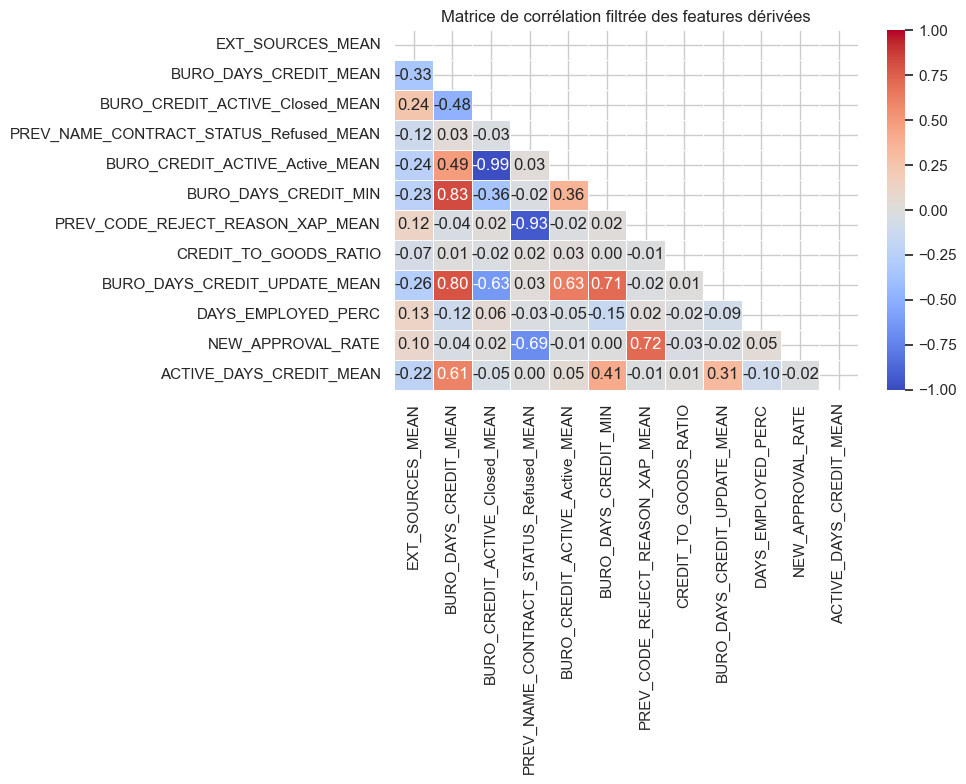

In [15]:
full_numeric_cols = [
    col
    for col in train_full.select_dtypes(include=[np.number]).columns.tolist()
    if col not in {"TARGET", "SK_ID_CURR"} and train_full[col].dropna().nunique() > 1
]

full_numeric_missing_rate = train_full[full_numeric_cols].isna().mean().rename("missing_ratio")
full_numeric_non_null = train_full[full_numeric_cols].notna().sum().rename("non_null_count")

full_numeric_corr = (
    train_full[full_numeric_cols]
    .corrwith(train_full["TARGET"])
    .rename("correlation_target")
    .to_frame()
)
full_numeric_corr["correlation_abs"] = full_numeric_corr["correlation_target"].abs()
full_numeric_corr = (
    full_numeric_corr
    .join(full_numeric_missing_rate, how="left")
    .join(full_numeric_non_null, how="left")
    .sort_values("correlation_abs", ascending=False)
    .reset_index(names="variable")
)

min_non_null_for_interpretation = max(500, int(len(train_full) * 0.10))

full_numeric_corr_filtered = full_numeric_corr.loc[
    (full_numeric_corr["missing_ratio"] <= 0.60)
    & (full_numeric_corr["non_null_count"] >= min_non_null_for_interpretation)
].copy()

engineered_focus = full_numeric_corr.loc[
    full_numeric_corr["variable"].isin(engineered_columns)
].copy()
engineered_focus_filtered = full_numeric_corr_filtered.loc[
    full_numeric_corr_filtered["variable"].isin(engineered_columns)
].copy()

print("Top 20 corrélations numériques après enrichissement (filtrées pour rester interprétables) :")
display(full_numeric_corr_filtered.head(20))

print("Top variables dérivées les plus informatives après filtrage de couverture :")
display(engineered_focus_filtered.head(20))

engineered_plot = engineered_focus_filtered.loc[
    (engineered_focus_filtered["correlation_abs"] >= numeric_corr_threshold)
    & (engineered_focus_filtered["missing_ratio"] <= 0.40)
].head(top_numeric_heatmap_n)

if len(engineered_plot) >= 2:
    engineered_sample = sample_for_plot(train_full[engineered_plot["variable"].tolist()])
    engineered_sample = engineered_sample.loc[
        :,
        engineered_sample.nunique(dropna=True) > 1,
    ]

    engineered_corr_matrix = engineered_sample.corr(method="spearman")
    mask = np.triu(np.ones_like(engineered_corr_matrix, dtype=bool))

    if engineered_corr_matrix.shape[0] >= 2:
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(
            engineered_corr_matrix,
            mask=mask,
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            ax=ax,
        )
        ax.set_title("Matrice de corrélation filtrée des features dérivées")
        plt.tight_layout()
        plt.show()

full_numeric_corr.to_csv(processed_dir / "full_numeric_target_correlation.csv", index=False)
full_numeric_corr_filtered.to_csv(
    processed_dir / "full_numeric_target_correlation_filtered.csv",
    index=False,
)


**Etape 10 - Export des livrables**

Avant export, le dataset final reste riche mais maîtrisé :

- `606` variables conservent encore des valeurs manquantes après la fusion ;
- ces manquants concernent surtout des agrégats `REFUSED_*` et `CC_*`, ce qui est cohérent : tous les clients n'ont pas d'historique de refus ou de carte ;
- après l'imputation médiane finale, la matrice model-ready ne contient plus aucune valeur manquante et compte `468` features.

Décisions :

- conserver les `NaN` comme signal structurel jusqu'à la fin du pipeline, puis imputer seulement au moment de produire la matrice d'entraînement ;
- garder les agrégats `bureau` et `previous_application` dans la suite, car ils dominent les meilleures corrélations enrichies ;
- exporter à la fois le dataset enrichi et la documentation de preprocessing pour que la modélisation reste traçable et reproductible.


In [16]:
train_output_path = processed_dir / "application_train_full.parquet"
test_output_path = processed_dir / "application_test_full.parquet"

train_full.to_parquet(train_output_path, index=False)
test_full.to_parquet(test_output_path, index=False)

model_recommendation = {
    "target_column": "TARGET",
    "class_imbalance_ratio": float(app_train["TARGET"].mean()),
    "join_strategy": "left join on SK_ID_CURR after aggregation of child tables",
    "encoding_strategy": {
        "binary_variables": "manual 0/1 mapping when the variable has two clear modalities",
        "nominal_variables": "one-hot encoding via pandas get_dummies inside reusable helpers",
        "why": "compatible with linear models and tree-based models",
    },
    "missing_value_strategy": {
        "analysis_first": "missing values are documented before any aggressive deletion",
        "model_ready_preview": "median imputation with SimpleImputer on the final numeric matrix",
    },
    "recommended_first_models": [
        "LogisticRegression",
        "RandomForest",
        "LightGBM",
    ],
}

with (processed_dir / "model_recommendation.json").open("w", encoding="utf-8") as file:
    json.dump(model_recommendation, file, indent=2)

print("Export terminé :")
print(train_output_path)
print(test_output_path)
print(processed_dir / "join_report.csv")
print(processed_dir / "final_missing_report.csv")
print(processed_dir / "model_recommendation.json")


Export terminé :
C:\Users\kevin\Documents\P6\P6_MLOps_1-2\data\processed\application_train_full.parquet
C:\Users\kevin\Documents\P6\P6_MLOps_1-2\data\processed\application_test_full.parquet
C:\Users\kevin\Documents\P6\P6_MLOps_1-2\data\processed\join_report.csv
C:\Users\kevin\Documents\P6\P6_MLOps_1-2\data\processed\final_missing_report.csv
C:\Users\kevin\Documents\P6\P6_MLOps_1-2\data\processed\model_recommendation.json


## Conclusion Du Notebook

A la fin de ce notebook, nous avons obtenu un jeu de données propre, fusionné et exploitable pour l'entraînement :

- `8` sources brutes ont été contrôlées et leur granularité a été documentée ;
- la cible est déséquilibrée avec seulement `8,07 %` de défauts, ce qui oriente déjà le choix des métriques et de la validation ;
- les signaux bruts les plus importants viennent surtout des `EXT_SOURCE`, de l'âge et de variables temporelles ;
- les signaux catégoriels les plus utiles viennent principalement de la profession, du type d'organisation, du revenu et du niveau d'éducation ;
- la fusion multi-sources n'a créé aucune inflation de lignes grâce à l'agrégation préalable ;
- après encodage, pruning et imputation finale, le dataset d'entraînement contient `468` features model-ready sans valeurs manquantes.

Décisions retenues pour la suite :

- utiliser une validation croisée stratifiée ;
- comparer les modéles avec des métriques adaptées au déséquilibre et au coût métier ;
- conserver les agrégats `bureau` et `previous_application`, qui enrichissent réellement le signal ;
- poursuivre dans le notebook de modélisation avec un pipeline explicite de preprocessing, de sélection, d'optimisation et de suivi MLflow.
